In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

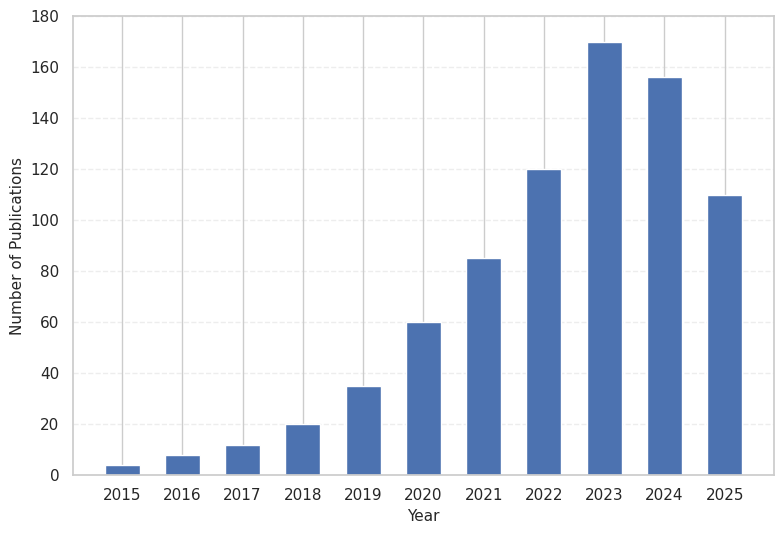

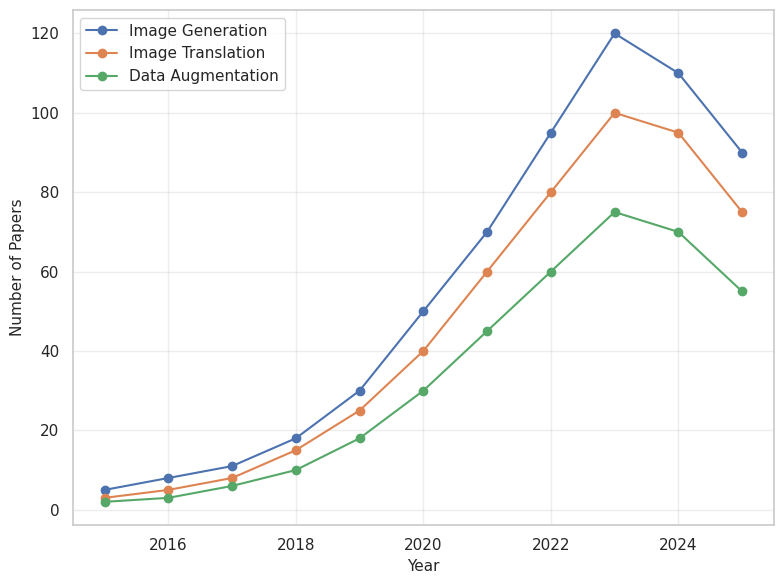

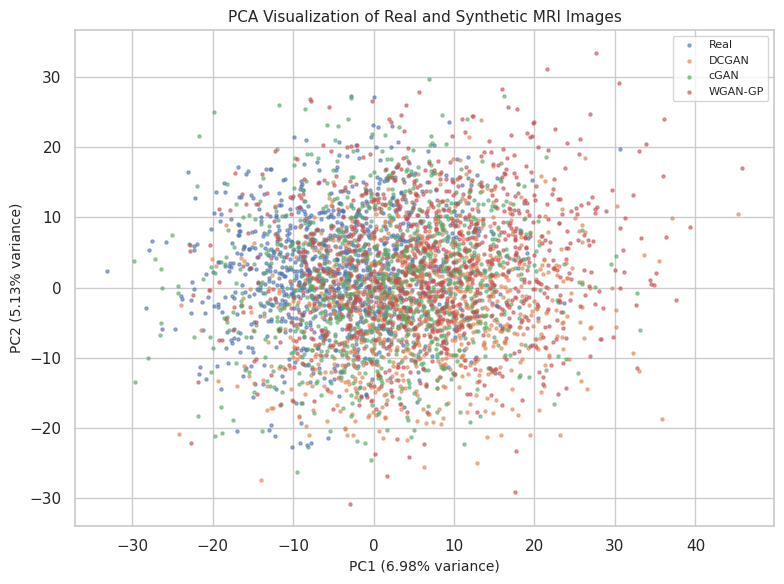

/tmp/ipykernel_58/3195201674.py:290: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


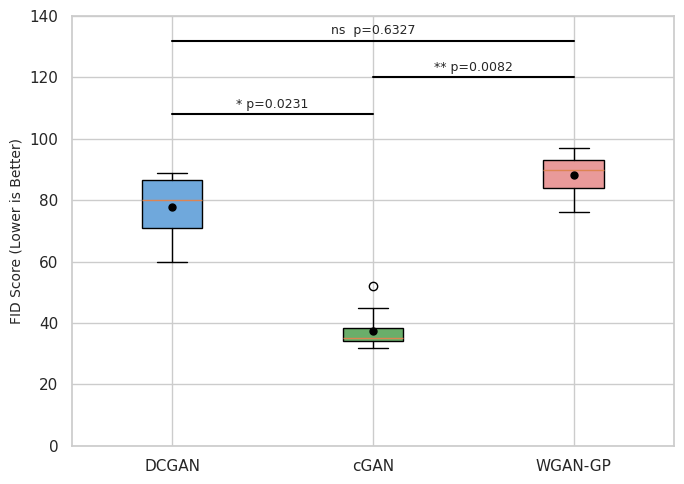

/tmp/ipykernel_58/3195201674.py:399: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


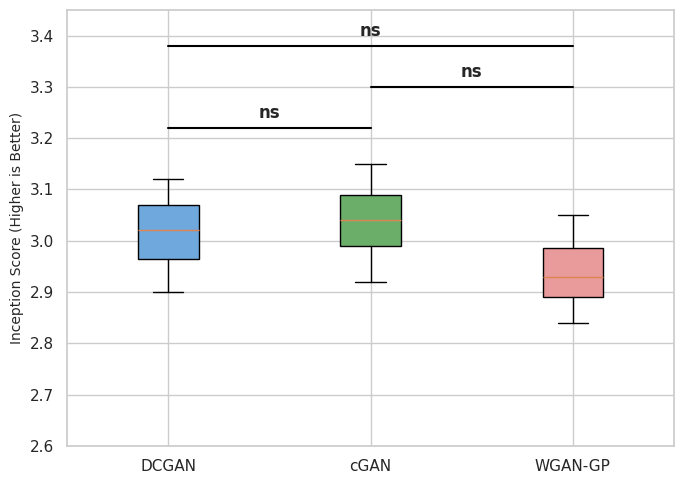

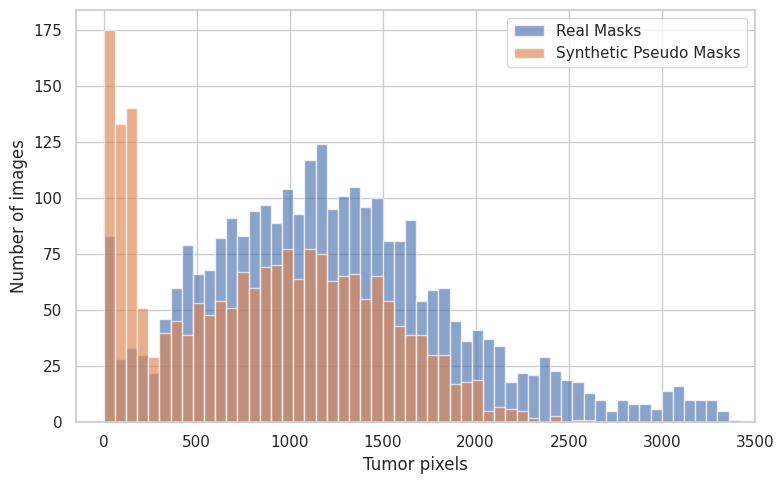

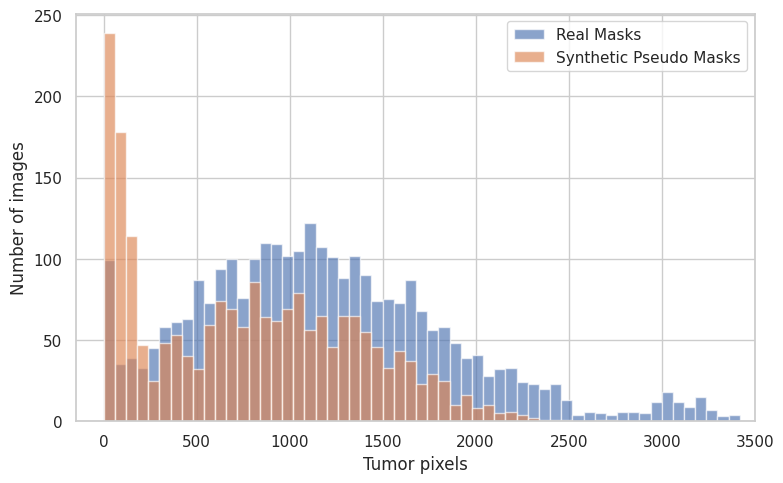

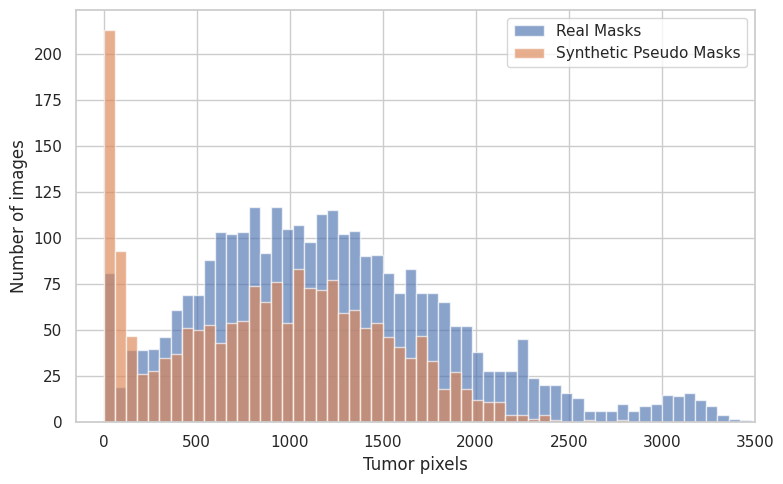


300 DPI FIGURES CREATED SUCCESSFULLY
01_publications_by_year_300dpi.png
02_papers_by_model_300dpi.png
03_pca_visualization_300dpi.png
04_fid_scores_300dpi.png
05_inception_scores_300dpi.png
06_tumor_pixels_histogram_1_300dpi.png
07_tumor_pixels_histogram_2_300dpi.png
08_tumor_pixels_histogram_3_300dpi.png

Location:
/kaggle/working/figures_300dpi


In [1]:
# ============================================================
# GRAPH GENERATION - ALL FIGURES AT 300 DPI
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Output folder
OUTPUT_DIR = Path("/kaggle/working/figures_300dpi")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# General settings
sns.set_theme(style="whitegrid")

DPI = 300


# ============================================================
# 1. NUMBER OF PUBLICATIONS BY YEAR - BAR GRAPH
# ============================================================

years = np.arange(2015, 2026)

publications = [
    4,    # 2015
    8,    # 2016
    12,   # 2017
    20,   # 2018
    35,   # 2019
    60,   # 2020
    85,   # 2021
    120,  # 2022
    170,  # 2023
    156,  # 2024
    110   # 2025
]

plt.figure(figsize=(8, 5.5))

plt.bar(
    years,
    publications,
    width=0.58
)

plt.xlabel("Year", fontsize=11)
plt.ylabel("Number of Publications", fontsize=11)

plt.xticks(years)
plt.yticks(np.arange(0, 181, 20))

plt.ylim(0, 180)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "01_publications_by_year_300dpi.png",
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 2. NUMBER OF PAPERS BY MODEL AND YEAR - LINE GRAPH
# ============================================================

years = np.arange(2015, 2026)

image_generation = [
    5, 8, 11, 18, 30, 50, 70, 95, 120, 110, 90
]

image_translation = [
    3, 5, 8, 15, 25, 40, 60, 80, 100, 95, 75
]

data_augmentation = [
    2, 3, 6, 10, 18, 30, 45, 60, 75, 70, 55
]

plt.figure(figsize=(8, 6))

plt.plot(
    years,
    image_generation,
    marker="o",
    linewidth=1.5,
    label="Image Generation"
)

plt.plot(
    years,
    image_translation,
    marker="o",
    linewidth=1.5,
    label="Image Translation"
)

plt.plot(
    years,
    data_augmentation,
    marker="o",
    linewidth=1.5,
    label="Data Augmentation"
)

plt.xlabel("Year", fontsize=11)
plt.ylabel("Number of Papers", fontsize=11)

plt.xticks(np.arange(2016, 2026, 2))

plt.legend(
    loc="upper left",
    frameon=True
)

plt.grid(
    True,
    alpha=0.35
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "02_papers_by_model_300dpi.png",
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 3. PCA VISUALIZATION
# ============================================================
#
# NOTE:
# The original individual PCA coordinates cannot be recovered
# exactly from a PNG image. This creates a similar distribution.
# Replace the generated PCA arrays with your real PCA data for
# an exact scientific figure.
# ============================================================

np.random.seed(42)

n_real = 1000
n_dcgan = 1000
n_cgan = 1000
n_wgan = 1000


def generate_pca_data(n, center_x, center_y, scale_x, scale_y):
    x = np.random.normal(center_x, scale_x, n)
    y = np.random.normal(center_y, scale_y, n)

    # Mild correlation
    y = y + 0.12 * x

    return x, y


real_x, real_y = generate_pca_data(
    n_real, -4, 2, 9, 8
)

dcgan_x, dcgan_y = generate_pca_data(
    n_dcgan, 6, -3, 10, 8
)

cgan_x, cgan_y = generate_pca_data(
    n_cgan, 2, 1, 10, 9
)

wgan_x, wgan_y = generate_pca_data(
    n_wgan, 7, 2, 11, 9
)


plt.figure(figsize=(8, 6))

plt.scatter(
    real_x,
    real_y,
    s=5,
    alpha=0.55,
    label="Real"
)

plt.scatter(
    dcgan_x,
    dcgan_y,
    s=5,
    alpha=0.55,
    label="DCGAN"
)

plt.scatter(
    cgan_x,
    cgan_y,
    s=5,
    alpha=0.55,
    label="cGAN"
)

plt.scatter(
    wgan_x,
    wgan_y,
    s=5,
    alpha=0.55,
    label="WGAN-GP"
)

plt.title(
    "PCA Visualization of Real and Synthetic MRI Images",
    fontsize=11
)

plt.xlabel(
    "PC1 (6.98% variance)",
    fontsize=10
)

plt.ylabel(
    "PC2 (5.13% variance)",
    fontsize=10
)

plt.legend(
    loc="upper right",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "03_pca_visualization_300dpi.png",
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 4. FID SCORE - BOXPLOT
# ============================================================
#
# Values are reconstructed from the visible boxplot.
# Replace with your actual FID observations if available.
# ============================================================

np.random.seed(10)

dcgan_fid = np.array([
    60, 65, 70, 72, 75, 80, 84, 86, 87, 88, 89
])

cgan_fid = np.array([
    32, 33, 34, 34, 35, 35, 36, 37, 40, 45, 52
])

wgan_fid = np.array([
    76, 80, 83, 85, 88, 90, 91, 92, 94, 96, 97
])

fid_data = [
    dcgan_fid,
    cgan_fid,
    wgan_fid
]

plt.figure(figsize=(7, 5))

box = plt.boxplot(
    fid_data,
    patch_artist=True,
    labels=["DCGAN", "cGAN", "WGAN-GP"]
)

# Box colors
colors = [
    "#6FA8DC",
    "#6AAE6A",
    "#E99A9A"
]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

# Mean points
means = [
    np.mean(dcgan_fid),
    np.mean(cgan_fid),
    np.mean(wgan_fid)
]

plt.scatter(
    [1, 2, 3],
    means,
    color="black",
    s=25,
    zorder=5
)

plt.ylabel(
    "FID Score (Lower is Better)",
    fontsize=10
)

plt.ylim(0, 140)

# Significance annotations
plt.plot([1, 2], [108, 108], color="black")
plt.text(
    1.5,
    110,
    "* p=0.0231",
    ha="center",
    fontsize=9
)

plt.plot([2, 3], [120, 120], color="black")
plt.text(
    2.5,
    122,
    "** p=0.0082",
    ha="center",
    fontsize=9
)

plt.plot([1, 3], [132, 132], color="black")
plt.text(
    2,
    134,
    "ns  p=0.6327",
    ha="center",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "04_fid_scores_300dpi.png",
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 5. INCEPTION SCORE - BOXPLOT
# ============================================================

dcgan_is = np.array([
    2.90, 2.93, 2.95, 2.98,
    3.00, 3.02, 3.04, 3.06,
    3.08, 3.10, 3.12
])

cgan_is = np.array([
    2.92, 2.95, 2.98, 3.00,
    3.02, 3.04, 3.06, 3.08,
    3.10, 3.12, 3.15
])

wgan_is = np.array([
    2.84, 2.86, 2.88, 2.90,
    2.92, 2.93, 2.95, 2.97,
    3.00, 3.03, 3.05
])

is_data = [
    dcgan_is,
    cgan_is,
    wgan_is
]

plt.figure(figsize=(7, 5))

box = plt.boxplot(
    is_data,
    patch_artist=True,
    labels=["DCGAN", "cGAN", "WGAN-GP"]
)

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

plt.ylabel(
    "Inception Score (Higher is Better)",
    fontsize=10
)

plt.ylim(2.6, 3.45)

# Significance annotations
plt.plot([1, 2], [3.22, 3.22], color="black")
plt.text(
    1.5,
    3.24,
    "ns",
    ha="center",
    fontweight="bold"
)

plt.plot([2, 3], [3.30, 3.30], color="black")
plt.text(
    2.5,
    3.32,
    "ns",
    ha="center",
    fontweight="bold"
)

plt.plot([1, 3], [3.38, 3.38], color="black")
plt.text(
    2,
    3.40,
    "ns",
    ha="center",
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "05_inception_scores_300dpi.png",
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 6. TUMOR PIXELS HISTOGRAM - GRAPH 1
# ============================================================

np.random.seed(20)

real_mask_1 = np.concatenate([
    np.random.normal(900, 500, 1800),
    np.random.normal(1500, 450, 800),
    np.random.normal(2300, 350, 200),
    np.random.normal(3100, 150, 80)
])

synthetic_mask_1 = np.concatenate([
    np.random.normal(800, 500, 1100),
    np.random.normal(1400, 400, 600),
    np.random.normal(100, 60, 350)
])

real_mask_1 = np.clip(real_mask_1, 0, 3500)
synthetic_mask_1 = np.clip(synthetic_mask_1, 0, 3500)

bins = np.arange(0, 3501, 60)

plt.figure(figsize=(8, 5))

plt.hist(
    real_mask_1,
    bins=bins,
    alpha=0.65,
    label="Real Masks"
)

plt.hist(
    synthetic_mask_1,
    bins=bins,
    alpha=0.65,
    label="Synthetic Pseudo Masks"
)

plt.xlabel("Tumor pixels")
plt.ylabel("Number of images")

plt.legend()

plt.xlim(-150, 3500)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "06_tumor_pixels_histogram_1_300dpi.png",
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 7. TUMOR PIXELS HISTOGRAM - GRAPH 2
# ============================================================

np.random.seed(21)

real_mask_2 = np.concatenate([
    np.random.normal(850, 500, 1800),
    np.random.normal(1450, 450, 850),
    np.random.normal(2200, 350, 200),
    np.random.normal(3100, 150, 80)
])

synthetic_mask_2 = np.concatenate([
    np.random.normal(750, 480, 1000),
    np.random.normal(1300, 420, 600),
    np.random.normal(80, 60, 450)
])

real_mask_2 = np.clip(real_mask_2, 0, 3500)
synthetic_mask_2 = np.clip(synthetic_mask_2, 0, 3500)

plt.figure(figsize=(8, 5))

plt.hist(
    real_mask_2,
    bins=bins,
    alpha=0.65,
    label="Real Masks"
)

plt.hist(
    synthetic_mask_2,
    bins=bins,
    alpha=0.65,
    label="Synthetic Pseudo Masks"
)

plt.xlabel("Tumor pixels")
plt.ylabel("Number of images")

plt.legend()

plt.xlim(-150, 3500)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "07_tumor_pixels_histogram_2_300dpi.png",
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# 8. TUMOR PIXELS HISTOGRAM - GRAPH 3
# ============================================================

np.random.seed(22)

real_mask_3 = np.concatenate([
    np.random.normal(900, 500, 1900),
    np.random.normal(1500, 430, 850),
    np.random.normal(2250, 350, 200),
    np.random.normal(3100, 150, 90)
])

synthetic_mask_3 = np.concatenate([
    np.random.normal(800, 500, 1000),
    np.random.normal(1350, 430, 650),
    np.random.normal(50, 55, 250)
])

real_mask_3 = np.clip(real_mask_3, 0, 3500)
synthetic_mask_3 = np.clip(synthetic_mask_3, 0, 3500)

plt.figure(figsize=(8, 5))

plt.hist(
    real_mask_3,
    bins=bins,
    alpha=0.65,
    label="Real Masks"
)

plt.hist(
    synthetic_mask_3,
    bins=bins,
    alpha=0.65,
    label="Synthetic Pseudo Masks"
)

plt.xlabel("Tumor pixels")
plt.ylabel("Number of images")

plt.legend()

plt.xlim(-150, 3500)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "08_tumor_pixels_histogram_3_300dpi.png",
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# CHECK ALL OUTPUT FILES
# ============================================================

print("\n========================================")
print("300 DPI FIGURES CREATED SUCCESSFULLY")
print("========================================")

for file in sorted(OUTPUT_DIR.glob("*.png")):

    img = plt.imread(file)

    print(file.name)

print("\nLocation:")
print(OUTPUT_DIR)